In [1]:
from pyprojroot import here
print("Project root:", here())

Project root: C:\Users\hanis\Flight\flight-delay-prediction


# Relationship EDA

### The phase of data analysis where you look at how two or more variables interact with each other.
Let's start by seeing all the columns present

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load train data
df = pd.read_parquet(here("data/processed/train.parquet"))
print(df.columns)
df.head()

Index(['Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline',
       'DOT_ID_Reporting_Airline', 'IATA_CODE_Reporting_Airline',
       'Tail_Number', 'Flight_Number_Reporting_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest',
       'DestCityName', 'DestState', 'DestStateFips', 'DestStateName',
       'DestWac', 'CRSDepTime', 'DepDel15', 'DepTimeBlk', 'CRSArrTime',
       'ArrTimeBlk', 'CRSElapsedTime', 'Distance', 'DistanceGroup'],
      dtype='object')


,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,...,DestStateName,DestWac,CRSDepTime,DepDel15,DepTimeBlk,CRSArrTime,ArrTimeBlk,CRSElapsedTime,Distance,DistanceGroup
0,10,29,2,2024-10-29,UA,19977,UA,N37504,1885.0,11618,...,Arizona,81,1300,0.0,1300-1359,1532,1500-1559,332.0,2133.0,9
1,10,29,2,2024-10-29,UA,19977,UA,N69824,1884.0,11292,...,Montana,84,1920,0.0,1900-1959,2056,2000-2059,96.0,455.0,2
2,10,29,2,2024-10-29,UA,19977,UA,N37297,1883.0,13930,...,Texas,74,907,0.0,0900-0959,1218,1200-1259,191.0,1041.0,5
3,10,29,2,2024-10-29,UA,19977,UA,N47569,1882.0,13930,...,Colorado,82,1315,0.0,1300-1359,1505,1500-1559,170.0,888.0,4
4,10,29,2,2024-10-29,UA,19977,UA,N69826,1878.0,13930,...,California,91,1245,0.0,1200-1259,1538,1500-1559,293.0,1846.0,8


# 1. Hour of the day vs DepDelay15

#### Observations

1. Delay rate exhibits a clear time-of-day pattern. It is relatively high around midnight (~21%), reaches its lowest levels during the early morning hours (approximately 05:00–06:00, ~6%), rises steadily throughout the day, peaks during the early evening (around 20:00 at ~28%), and then begins to decline late at night.

2. The increase in delays throughout the day is consistent with delay propagation. Aircraft and crews are reused across multiple flights, so delays from earlier flights cascade into later departures. The elevated delay rates around midnight likely reflect the final flights of the operating day, which still inherit accumulated delay before the schedule effectively resets during the pre-dawn hours.

3. Flight volume is highest during the morning and midday periods and gradually decreases toward the late evening. Departure hours 02:00–04:00 carry only a few hundred flights each (hour 04 has just 17), so delay rates in those buckets are noisy and should not be over-interpreted.

4. Overlaying flight volume on the delay-rate curve makes the reliable region clear: the smooth morning-to-evening rise rests on hundreds of thousands of flights, while the late-night points rest on almost none.

#### Conclusion

Departure delay rate varies substantially across the operating day, lowest in the early morning and highest in the evening, consistent with delay accumulation as aircraft and crews are reused. Scheduled departure hour is therefore expected to be one of the most informative features for predicting delay, though its relationship is non-linear and is best captured by tree-based models or an engineered daypart feature rather than a raw linear term.

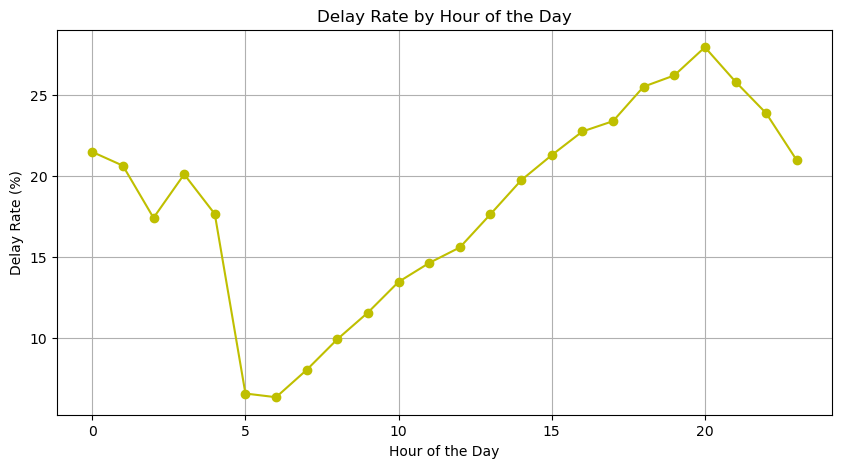

    dep_hour  total_flights  delay_rate
0          0           2929   21.474906
1          1            766   20.626632
2          2            247   17.408907
3          3            209   20.095694
4          4             17   17.647059
5          5          46909    6.572300
6          6         121752    6.344044
7          7         127541    8.030359
8          8         125882    9.920402
9          9         102089   11.569317
10        10         112707   13.459679
11        11         116658   14.626515
12        12         106233   15.584611
13        13         108116   17.633838
14        14         106036   19.723490
15        15         102996   21.277525
16        16         104470   22.735714
17        17         112527   23.373057
18        18         110168   25.501961
19        19          95247   26.194001
20        20          78693   27.933870
21        21          54550   25.803850
22        22          40079   23.860376
23        23          14258   20.956656


In [3]:
df["dep_hour"] = df["CRSDepTime"] // 100

hour_wise_delay = (
    df.groupby("dep_hour")
    .agg(
        total_flights = ("DepDel15", "count"),
        delay_rate = ("DepDel15", "mean")
    )
    .reset_index()
)
hour_wise_delay["delay_rate"] *= 100

plt.figure(figsize=(10,5))

plt.plot(
    hour_wise_delay["dep_hour"],
    hour_wise_delay["delay_rate"],
    marker="o",
    color = "y"
)

plt.xlabel("Hour of the Day")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Hour of the Day")

plt.grid(True)
plt.show()

print(hour_wise_delay)

# 2. Airline vs DepDel15

### Observations (training set, Aug–Oct 2024)
1. Delay rates vary substantially across carriers, from ~10% to ~25%.
2. Worst: F9 (Frontier) at 25.3%, followed by B6 (22.8%) and NK (22.1%).
3. Best: YX at 10.0%, essentially tied with HA at 10.0%.
4. The worst-to-best gap is ~2.5×.

Possible drivers (not tested here): route networks, hub airports, fleet
utilization, operational practices. Likely confounder: a carrier's delay rate
partly reflects WHICH airports/routes it flies, not the carrier alone — e.g.
HA flies mostly low-congestion Hawaii routes. Part of this "airline effect"
may actually be geography.

### Report
On the training data, departure-delay rates differ markedly across airlines
(~10%–25%, a ~2.5× spread), indicating airline identity carries predictive
signal. Some variation likely reflects each carrier's route network and origin
mix rather than the carrier itself, so airline is expected to be a useful but
partly confounded predictor.

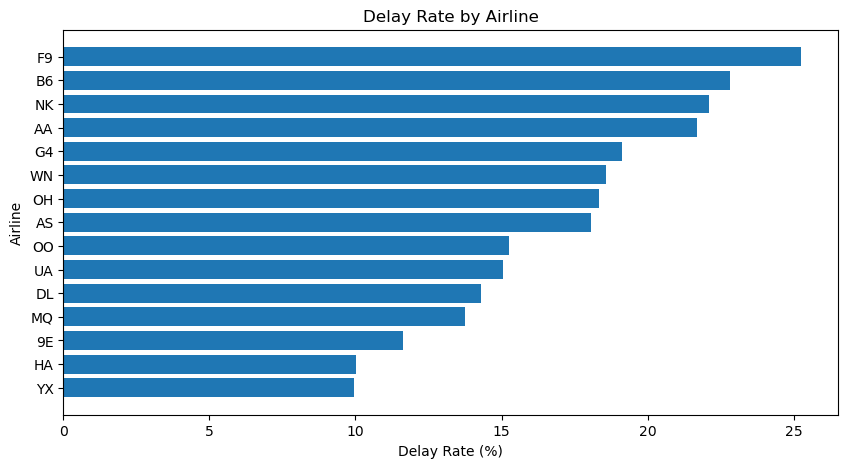

   Reporting_Airline  total_flights  delay_rate
13                WN         346512   18.588967
4                 DL         260908   14.305809
1                 AA         249195   21.685026
11                OO         198166   15.246309
12                UA         195817   15.052830
14                YX          76411    9.965843
8                 MQ          72605   13.745610
2                 AS          64579   18.073987
9                 NK          64514   22.088229
10                OH          60536   18.342804
3                 B6          56847   22.833219
5                 F9          52585   25.269564
0                 9E          48439   11.643510
6                 G4          24325   19.120247
7                 HA          19640   10.015275


In [4]:
airline_delay = (
    df.groupby("Reporting_Airline")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

airline_delay["delay_rate"] *= 100

airline_delay.sort_values(
    "delay_rate",
    ascending=True,
    inplace=True
)

plt.figure(figsize=(10,5))

plt.barh(
    airline_delay["Reporting_Airline"],
    airline_delay["delay_rate"]
)


plt.xlabel("Delay Rate (%)")
plt.ylabel("Airline")
plt.title("Delay Rate by Airline")

airline_delay.sort_values(
    "total_flights",
    ascending=False,
    inplace=True
)
plt.show()

print(airline_delay)

# 3. Day of Week vs Departure Delay

#### Observations
1. Flight volume is relatively consistent across the week, ranging from
   approximately 224,000 flights on Day 6 to 286,000 on Day 4. Day 6 stands
   out as the lightest day, while the rest sit in a fairly narrow band.
2. Delay rates vary noticeably across the week, ranging from 12.5% on Day 2
   to 21.0% on Day 5. This suggests the day of the week may influence the
   likelihood of departure delay.
3. Days 2 and 3 have distinctly lower delay rates (~12.5–12.9%), while the
   remaining days are higher, peaking on Day 5. Day 1 is also elevated (18.0%),
   so the effect is concentrated in a mid-week dip rather than a clean
   first-half / second-half split.

#### Conclusion
The day of the week has a meaningful relationship with departure delay. Because
delay rates differ substantially across days despite broadly similar flight
volumes, the day of the week is likely to be a useful predictive feature —
though the signal is driven mainly by the low-delay mid-week days (2–3) versus
the busier end of the week.

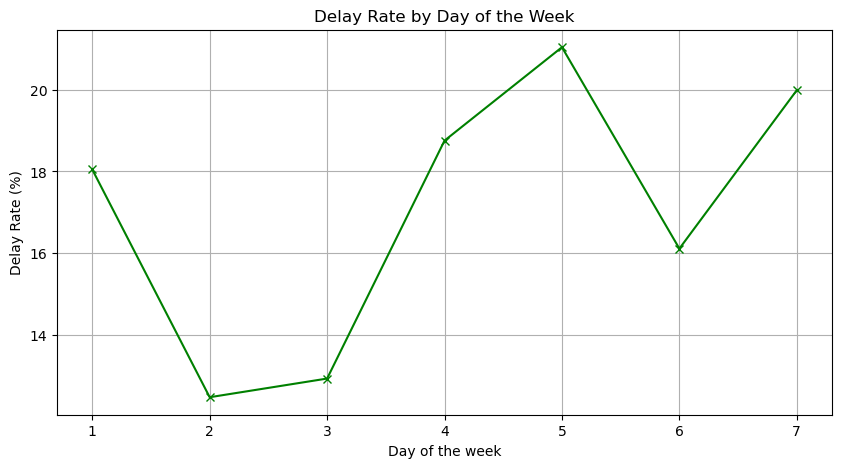

   DayOfWeek  total_flights  delay_rate
0          1         268314   18.048257
1          2         237620   12.472435
2          3         240128   12.929354
3          4         286103   18.754784
4          5         269294   21.040944
5          6         224004   16.110427
6          7         265616   19.989007


In [5]:
dayOfWeek_delay = (
    df.groupby("DayOfWeek")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

dayOfWeek_delay["delay_rate"] *= 100

plt.figure(figsize=(10,5))

plt.plot(
    dayOfWeek_delay["DayOfWeek"],
    dayOfWeek_delay["delay_rate"],
    marker="x",
    color = 'g'
)

plt.xlabel("Day of the week")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Day of the Week")

plt.grid(True)
plt.show()

print(dayOfWeek_delay)


# 4. Airport vs DepDel15
### Origin Airport vs Departure Delay

#### Observations
1. Significant variation exists in delay rates across the busiest airports,
   ranging from approximately 14% at LAX to 24% at CLT. DFW is also high at
   ~21.6%.
2. Some of the busiest airports, such as ATL, show relatively moderate delay
   rates (15.9%) despite handling the highest flight volume (~87k flights).
   High traffic alone does not necessarily produce higher delays.
3. Airports such as CLT (24.2%) and DFW (21.6%) run noticeably higher than
   other major airports, indicating that airport-specific operational factors
   influence departure performance.
4. The gap between the highest and lowest delay rates among these top airports
   is roughly 10 percentage points (CLT ~24% vs LAX ~14%) — a substantial
   spread compared with several other features analysed.

#### Conclusion
The origin airport has a meaningful relationship with departure delay. Because
delay rates vary considerably

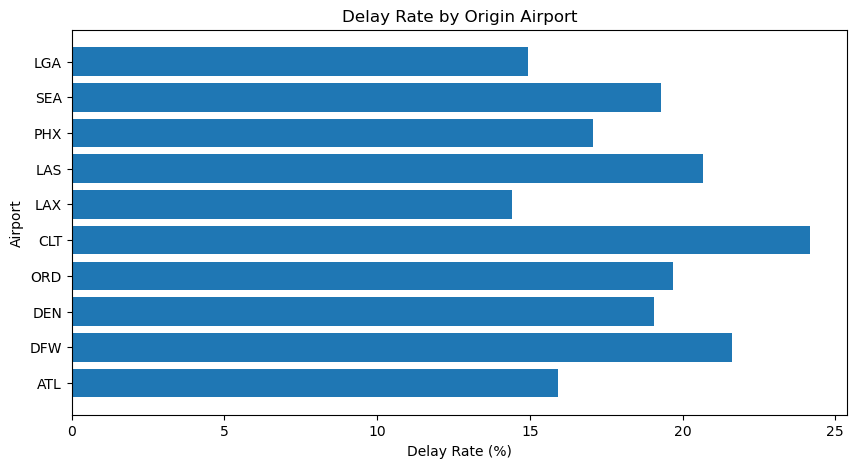

    Origin  total_flights  delay_rate
20     ATL          86597   15.917411
90     DFW          81337   21.624845
89     DEN          79875   19.074804
235    ORD          74878   19.673335
69     CLT          56304   24.167022
181    LAX          49683   14.409355
179    LAS          48547   20.662451
246    PHX          47188   17.061541
291    SEA          44236   19.307804
190    LGA          40501   14.940372


In [6]:
airport_delay = (
    df.groupby("Origin")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

airport_delay["delay_rate"] *= 100

top10_airports = airport_delay.sort_values(
    by="total_flights",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10_airports["Origin"],
    top10_airports["delay_rate"]
)


plt.xlabel("Delay Rate (%)")
plt.ylabel("Airport")
plt.title("Delay Rate by Origin Airport")

plt.show()

print(top10_airports)

# 5. Distance vs Departure Delay

#### Observations
1. Distance does not exhibit a strong monotonic relationship with departure
   delay rate. The variation across distance groups is relatively small
   (~15.5% to ~19%).
2. Delay rates generally rise from the shortest groups to the medium groups,
   peaking around groups 5–7 (~19%), then drift slightly lower for the longest
   distances.
3. Short-distance flights have the lowest delay rates (approx 15.5%) while
   medium-distance flights are highest (~19%). The difference is modest,
   so distance alone is not a dominant driver of delay.
4. Flight volume peaks at distance group 2 (~426k flights), not the shortest
   group, then declines as distance increases. Short- and medium-haul routes
   are far more common than long-haul ones.

#### Conclusion
Distance has only a moderate relationship with departure delay. While
medium-distance flights show slightly higher delay rates, the overall variation
is small, so distance by itself is unlikely to be a strong predictor and is
best combined with airline, airport, and departure-time features.

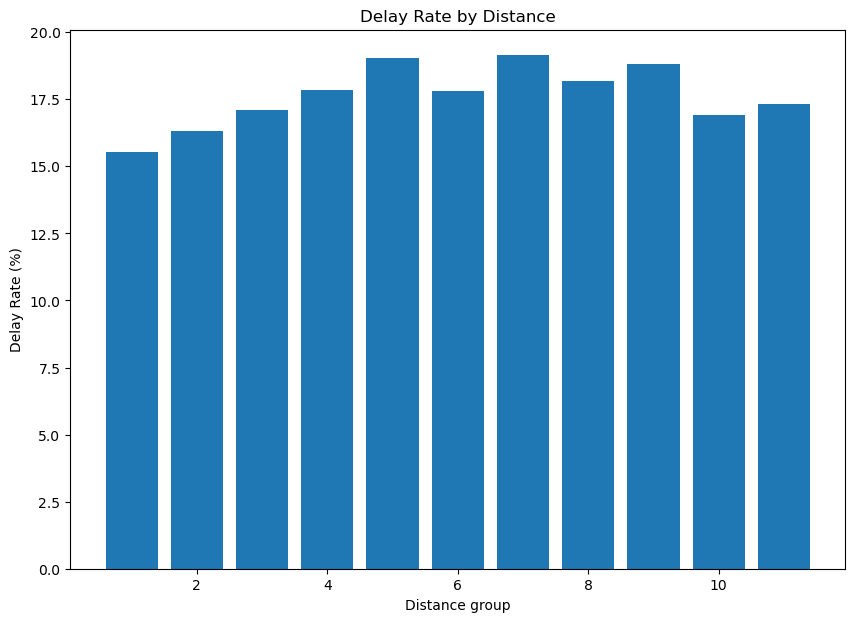

    DistanceGroup  total_flights  delay_rate
0               1         208890   15.540715
1               2         426485   16.303035
2               3         366669   17.103982
3               4         286092   17.858940
4               5         188388   19.035183
5               6          82403   17.800323
6               7          80547   19.135412
7               8          41854   18.170306
8               9          29536   18.814328
9              10          44368   16.897313
10             11          35847   17.326415


In [7]:
dist_delay = (
    df.groupby("DistanceGroup").agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    ).reset_index()
)

dist_delay["delay_rate"] *= 100

plt.figure(figsize=(10,7))

plt.bar(
    dist_delay["DistanceGroup"],
    dist_delay["delay_rate"]
)


plt.xlabel("Distance group")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Distance")

plt.show()

print(dist_delay)

# 6. Correlation Analysis(Heatmap)

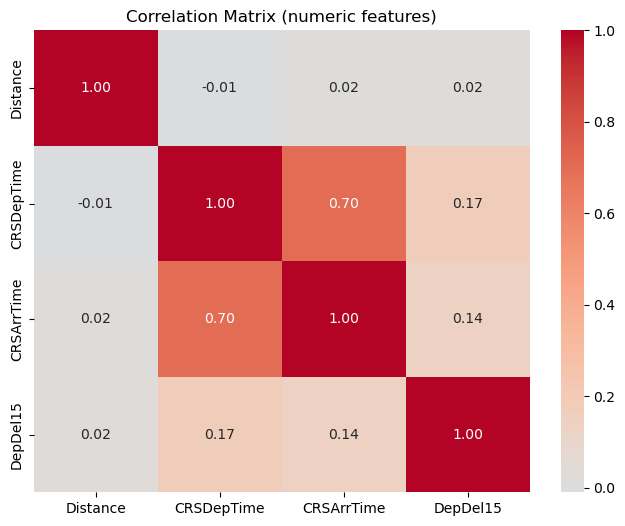

In [8]:
num_cols = ["Distance", "CRSDepTime", "CRSArrTime", "DepDel15"]

corr = df[num_cols].corr()   # Pearson by default

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (numeric features)")
plt.show()

### Correlation Analysis
A correlation heatmap was generated to examine linear relationships among the
numerical features.

#### Observations
1. CRSArrTime and CRSDepTime are strongly correlated (0.70) — flights scheduled
   to depart later are generally scheduled to arrive later. The two carry
   overlapping information, so both may not be needed as model inputs.
2. Distance has very weak correlations with all other numerical features,
   including the target DepDel15 (0.02), confirming distance alone is not a
   strong predictor.
3. DepDel15 shows only weak linear correlations with the numerical features,
   the highest being CRSDepTime at 0.17. Crucially, this understates the real
   effect: the departure-hour analysis showed delay rate ranging from ~6% to
   ~28% across the day. Pearson correlation measures only linear association, so
   it cannot capture this strong but non-linear time-of-day pattern.

#### Conclusion
No single numerical feature linearly explains departure delay. The weak
correlations reflect the limits of linear measures rather than an absence of
signal — the strongest driver (departure time) is non-linear. Categorical
variables such as airline and airport, together with engineered time features,
are therefore expected to be more important, and tree-based models (which handle
non-linearity natively) are likely a better fit than linear ones.